In [1]:
import sys
sys.path.append("../DeepGeSeq/")
print(sys.path)

['/root/miniconda3/lib/python312.zip', '/root/miniconda3/lib/python3.12', '/root/miniconda3/lib/python3.12/lib-dynload', '', '/root/dgs-tutorials/lib/python3.12/site-packages', '/root/miniconda3/lib/python3.12/site-packages', '../DeepGeSeq/']


In [2]:
import h5py, os, argparse, logging, time

import numpy as np
import pandas as pd

import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader

import DGS as dgs
from DGS.DL.Trainer import Trainer
from DGS.Model.Publications import DeepSEA
from DGS.DL.Evaluator import calculate_classification_metrics



libgomp: Invalid value for environment variable OMP_NUM_THREADS

libgomp: Invalid value for environment variable OMP_NUM_THREADS


In [3]:
os.makedirs("./Log", exist_ok=True)
dgs.initialize_logger(time.strftime('./Log/log_nvtk_deepsea.%m%d.%H:%M:%S.txt'), verbosity=1)

# args
parser = argparse.ArgumentParser()
parser.add_argument("data")
parser.add_argument("--gpu-device", dest="device_id", default="0")
args = parser.parse_args(['./data_scbasset_tutorial/Dataset.buen_ad_sc.X.h5', 
                          '--gpu-device', '0'])
logging.info(args)


In [4]:
## change device
os.environ["CUDA_VISIBLE_DEVICES"] = args.device_id
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Prepare dataset

1. unpack the h5file datasets
2. generate the DataLoader

In [5]:
# unpack datasets
h5file = h5py.File(args.data, 'r')
anno = h5file["peak"][:].astype(str)
X = h5file["X"][:].swapaxes(1,-1).astype(np.float32)
h5file.close()

X.shape

(103151, 4, 2000)

In [6]:
# unpack anno
n_tasks = anno.shape[0]
anno[:5]

array([['chr1', '9519', '11519', '182', 'True', 'False'],
       ['chr1', '12502', '14502', '41', 'True', 'False'],
       ['chr1', '15249', '17249', '49', 'True', 'False'],
       ['chr1', '95600', '97600', '107', 'True', 'False'],
       ['chr1', '114731', '116731', '21', 'True', 'False']], dtype='<U9')

In [7]:
train_sel = anno[:,4] == 'True'
test_sel = anno[:,5] == 'True'

In [8]:
x_train = X[train_sel][5000:]
x_val = X[train_sel][:5000]
x_test = X[test_sel]

x_train.shape, x_val.shape, x_test.shape

((93792, 4, 2000), (5000, 4, 2000), (4359, 4, 2000))

In [9]:
import anndata
fname = "./data_scbasset_tutorial/buen_ad_sc.h5ad"
ad = anndata.read_h5ad(fname)
ad

AnnData object with n_obs × n_vars = 2034 × 103151
    obs: 'cell_barcode', 'label', 'batch'
    var: 'chr', 'start', 'end', 'n_cells'
    uns: 'label_colors'

In [10]:
Y = ad.to_df().values.T
np.unique(Y)

array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
        11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
        22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,
        33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,
        44.,  45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,
        55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,
        66.,  67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,
        77.,  78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,
        88.,  89.,  90.,  91.,  92.,  93.,  95.,  96.,  97., 103., 105.,
       112., 114., 146.], dtype=float32)

In [11]:
Y = np.where(Y >= 1, 1., 0.)
Y = Y.astype(np.float32)
print(Y.shape)

np.unique(Y, return_counts=True)

(103151, 2034)


(array([0., 1.], dtype=float32), array([197088765,  12720369]))

In [12]:
y_train = Y[train_sel][5000:]
y_val = Y[train_sel][:5000]
y_test = Y[test_sel]

In [13]:
# define data loader
batch_size = 2_000
train_loader = DataLoader(list(zip(x_train, y_train)), batch_size=batch_size,
                            shuffle=True, num_workers=0, drop_last=False, pin_memory=True)
validate_loader = DataLoader(list(zip(x_val, y_val)), batch_size=batch_size, 
                            shuffle=False, num_workers=0, drop_last=False, pin_memory=True)
test_loader = DataLoader(list(zip(x_test, y_test)), batch_size=batch_size, 
                            shuffle=False, num_workers=0, drop_last=False, pin_memory=True)

## Define DeepSEA model
Initialized DeepSEA architectures in NvTK

In [16]:
import torch
from torch import nn

class Residual(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn = fn
    def forward(self, x, **kwargs):
        return self.fn(x, **kwargs) + x
        
class NvAtac(nn.Module):
    def __init__(self, n_tasks):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(4, 128, 11, 1, 5), nn.LeakyReLU(0.2),
            Residual(nn.Sequential(nn.Conv1d(128, 128, 9, 1, 4), nn.LeakyReLU(0.2))),
            nn.MaxPool1d(10), nn.Dropout(0.2),
            nn.Conv1d(128, 256, 7, 1, 3), nn.LeakyReLU(0.2),
            Residual(nn.Sequential(nn.Conv1d(256, 256, 5, 1, 2), nn.LeakyReLU(0.2))),
            nn.MaxPool1d(5), nn.Dropout(0.2),
            nn.Conv1d(256, 512, 3, 1, 1), nn.LeakyReLU(0.2),
            Residual(nn.Sequential(nn.Conv1d(512, 512, 3, 1, 1), nn.LeakyReLU(0.2))),
            nn.MaxPool1d(4), nn.Dropout(0.2),
            nn.Conv1d(512, 1024, 3, 1, 1), nn.LeakyReLU(0.2),
            Residual(nn.Sequential(nn.Conv1d(1024, 1024, 3, 1, 1), nn.LeakyReLU(0.2))),
            nn.MaxPool1d(2), nn.Dropout(0.2),
            )
        
        self.linear = nn.Sequential(
            nn.Linear(1024*5, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, n_tasks, bias=False),
            nn.Sigmoid()
            )
            
    def forward(self, x):
        x = self.conv(x) # bs, n_channels=1024, n_seq=4
        x = x.reshape(x.size(0), -1)
        x = self.linear(x)
        return x
    
model = NvAtac(n_tasks=2034)
model

NvAtac(
  (conv): Sequential(
    (0): Conv1d(4, 128, kernel_size=(11,), stride=(1,), padding=(5,))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Residual(
      (fn): Sequential(
        (0): Conv1d(128, 128, kernel_size=(9,), stride=(1,), padding=(4,))
        (1): LeakyReLU(negative_slope=0.2)
      )
    )
    (3): MaxPool1d(kernel_size=10, stride=10, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
    (5): Conv1d(128, 256, kernel_size=(7,), stride=(1,), padding=(3,))
    (6): LeakyReLU(negative_slope=0.2)
    (7): Residual(
      (fn): Sequential(
        (0): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=(2,))
        (1): LeakyReLU(negative_slope=0.2)
      )
    )
    (8): MaxPool1d(kernel_size=5, stride=5, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.2, inplace=False)
    (10): Conv1d(256, 512, kernel_size=(3,), stride=(1,), padding=(1,))
    (11): LeakyReLU(negative_slope=0.2)
    (12): Residual(
      (fn): Sequentia

In [18]:
optimizer = Adam([
    {'params': model.conv.parameters(), 'lr': 1e-4},
    {'params': model.linear.parameters(), 'lr': 1e-3}])
criterion = nn.BCELoss().to(device)
trainer = Trainer(model, criterion, optimizer, device, patience=20)


INFO:dgs:Trainer runtime options: use_amp=False, amp_dtype=torch.float16, non_blocking=False


## Trained the model 
as an example, we only finetune the DeepSEA model architectures on TFBS sub-dataset for 10 EPOCHs.

In [19]:
# train
trainer.train(train_loader, validate_loader, epochs=200)

Epoch 0: 100%|██████████| 47/47 [00:11<00:00,  4.07it/s, loss=0.2786]
INFO:dgs:Saved checkpoint to checkpoints/best_model.pt
INFO:dgs:
Epoch: 0
Time: 12.62s
Training Loss: 0.2786
Validation Loss: 0.2523
Validation Metric: 0.0000
Best Validation Loss: 0.2523
Best Validation Metric: 0.0000
Best Epoch: 0

Epoch 1: 100%|██████████| 47/47 [00:10<00:00,  4.29it/s, loss=0.2028]
INFO:dgs:
Epoch: 1
Time: 11.24s
Training Loss: 0.2028
Validation Loss: 0.2568
Validation Metric: 0.0000
Best Validation Loss: 0.2523
Best Validation Metric: 0.0000
Best Epoch: 0

Epoch 2: 100%|██████████| 47/47 [00:10<00:00,  4.45it/s, loss=0.2009]
INFO:dgs:
Epoch: 2
Time: 10.84s
Training Loss: 0.2009
Validation Loss: 0.2663
Validation Metric: 0.0000
Best Validation Loss: 0.2523
Best Validation Metric: 0.0000
Best Epoch: 0

Epoch 3: 100%|██████████| 47/47 [00:10<00:00,  4.36it/s, loss=0.1990]
INFO:dgs:
Epoch: 3
Time: 11.09s
Training Loss: 0.1990
Validation Loss: 0.2551
Validation Metric: 0.0000
Best Validation Loss: 0.

TrainerMetrics(train_losses=[0.27858261859163325, 0.20284349931047319, 0.20086099904902438, 0.19900745153427124, 0.19811904240161815, 0.19718528015816467, 0.19657431701396375, 0.19646501319205506, 0.19593015408262293, 0.19536784164449003, 0.19537211288797093, 0.1950531319734898, 0.19473562468873692, 0.19463629354821874, 0.19427831407557142, 0.19526234586188135, 0.19424953390943242, 0.19396940983356314, 0.19419758687628078, 0.19377550577863734, 0.19351732984502265, 0.19334021781353242, 0.19338208056510764, 0.19342070088741628, 0.19329623243910202, 0.19310408228255332, 0.19299492620407266, 0.19326429766543368, 0.1930763027135362, 0.19297209794216968, 0.192775067813853, 0.19267785771096008, 0.19294391128611058, 0.19247601133711795, 0.19269467509807425, 0.19260700015311547, 0.1922049601661398, 0.1921465555404095, 0.1921347607957556, 0.19200179805146886, 0.19215285239067484, 0.1919777640636931, 0.1920972466468811, 0.1916014241411331, 0.191682257867874, 0.19172964451160837, 0.191595082587384

In [17]:
# if you have enabled tensorboard
# !tensorboard --logdir=runs --bind_all

## Evaluated the model

In [20]:
os.makedirs("Metric", exist_ok=True)

# predict test-set
_, _, test_predictions, test_targets = trainer.validate(test_loader, return_predictions=True)

In [21]:
# metric test-set
metric = calculate_classification_metrics(test_targets.cpu().data.numpy(), test_predictions.cpu().data.numpy())
metric.to_csv("Metric/Metric.perCell.csv")
metric

,auroc,auprc,f1,accuracy
task_0,0.784697,0.058550,0.000000,0.988529
task_1,0.842868,0.036702,0.000000,0.994494
task_2,0.758272,0.060631,0.000000,0.986924
task_3,0.813612,0.069286,0.000000,0.988300
task_4,0.757394,0.045036,0.000000,0.992429
...,...,...,...,...
task_2029,0.679917,0.366807,0.302267,0.872907
task_2030,0.704225,0.106538,0.000000,0.988071
task_2031,0.696816,0.226821,0.116343,0.926818
task_2032,0.743196,0.191932,0.019608,0.954118


In [22]:
# metric test-set
metric = calculate_classification_metrics(test_targets.cpu().data.numpy().T, test_predictions.cpu().data.numpy().T)
metric.index = ["peak_"+str(i) for i in range(metric.shape[0])]
metric.to_csv("Metric/Metric.perPeak.csv")
metric

,auroc,auprc,f1,accuracy
peak_0,0.765102,0.122739,0.000000,0.968535
peak_1,0.739586,0.454111,0.477401,0.636185
peak_2,0.721639,0.228163,0.132653,0.916421
peak_3,0.747414,0.028213,0.000000,0.987217
peak_4,0.688205,0.035845,0.000000,0.980826
...,...,...,...,...
peak_4354,0.734050,0.082561,0.000000,0.988692
peak_4355,0.720299,0.101240,0.000000,0.963127
peak_4356,0.722138,0.434451,0.111588,0.796460
peak_4357,0.358282,0.008538,0.000000,0.989184


In [23]:
# show_auc_curve(fpr=fpr, tpr=tpr, roc_auc=roc_auc, save=False, fig_size=(5, 4))

## Benchmark

In [24]:
cellanno = ad.obs.copy()
cellanno.index.name = None
cellanno.head()

,cell_barcode,label,batch
BM1077-CLP-Frozen-160106-13,BM1077-CLP-Frozen-160106-13,CLP,BM1077
BM1077-CLP-Frozen-160106-14,BM1077-CLP-Frozen-160106-14,CLP,BM1077
BM1077-CLP-Frozen-160106-2,BM1077-CLP-Frozen-160106-2,CLP,BM1077
BM1077-CLP-Frozen-160106-21,BM1077-CLP-Frozen-160106-21,CLP,BM1077
BM1077-CLP-Frozen-160106-27,BM1077-CLP-Frozen-160106-27,CLP,BM1077


In [25]:
metric = pd.read_csv("Metric/Metric.perCell.csv", index_col=0)
metric.head()

,auroc,auprc,f1,accuracy
task_0,0.784697,0.058550,0.0,0.988529
task_1,0.842868,0.036702,0.0,0.994494
task_2,0.758272,0.060631,0.0,0.986924
task_3,0.813612,0.069286,0.0,0.988300
task_4,0.757394,0.045036,0.0,0.992429


In [26]:
metric['celltype'] = cellanno['label'].values
metric['batch'] = cellanno['batch'].values
metric.head()

,auroc,auprc,f1,accuracy,celltype,batch
task_0,0.784697,0.058550,0.0,0.988529,CLP,BM1077
task_1,0.842868,0.036702,0.0,0.994494,CLP,BM1077
task_2,0.758272,0.060631,0.0,0.986924,CLP,BM1077
task_3,0.813612,0.069286,0.0,0.988300,CLP,BM1077
task_4,0.757394,0.045036,0.0,0.992429,CLP,BM1077


(0.3, 1.05)

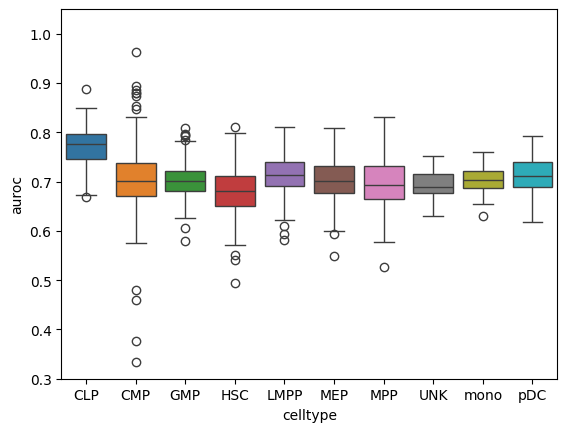

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(metric, x="celltype", y='auroc', hue="celltype")
plt.ylim(0.3,1.05)